In [40]:
import numpy as np
import pandas as pd
import pyextremes as pyext
import matplotlib.pyplot as plt

import wave_aux as wa

In [41]:
fin='./Point_out_000260.dat'
pdW=wa.readWave(1,'../data/'+fin,0)
pdW

,Hs,T02,T01,Tm10,Tp,Dirm,Dirp,Spr,Hs0,Tp0,...,Dirp2,gam2,spr2,Hs3,Tp3,Dirp3,gam3,spr3,uw,vw
YYYY-MM-DD hh:mm:ss,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00,0.000,1.52,1.52,1.52,1.96,270.0,227.3,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.51,5.12
1979-01-01 01:00:00,0.232,1.47,1.58,1.74,1.96,228.2,227.3,26.1,0.232,1.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.30,6.07
1979-01-01 02:00:00,0.706,2.23,2.41,2.65,3.02,229.1,226.5,31.7,0.706,3.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.40,8.38
1979-01-01 03:00:00,1.151,3.03,3.30,3.63,4.18,222.7,217.8,30.1,1.151,4.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.65,8.66
1979-01-01 04:00:00,1.472,3.66,4.00,4.42,5.08,219.4,216.1,27.6,1.472,5.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.12,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-30 20:00:00,1.140,4.57,5.20,6.09,7.52,205.5,221.8,37.8,NaN,NaN,...,152.6,2.24,0.5,0.257,4.43,280.2,2.20,0.4,-2.42,-2.08
2025-01-30 21:00:00,1.145,4.54,5.17,6.08,7.52,207.2,221.6,38.0,NaN,NaN,...,153.4,2.19,0.5,0.305,4.40,280.6,2.12,0.4,-2.58,-2.36
2025-01-30 22:00:00,1.154,4.46,5.10,6.02,7.51,209.0,221.2,39.2,NaN,NaN,...,159.3,2.27,0.4,0.356,4.37,281.0,2.06,0.5,-1.61,-0.75


In [42]:
model = pyext.EVA(pdW['Hs'])
model


/opt/miniforge3/envs/meteocean/lib/python3.10/site-packages/pyextremes/eva.py:112: RuntimeWarning: 1 duplicate indices found in `data` - removing duplicate entries
  warnings.warn(message=message, category=RuntimeWarning)


                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                            Hs      Size:                             403,968
Start:                       January 1979      End:                         January 2025
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Extreme values have not been extracted
                                         Model                                          
----------------------------------------------------------------------------------------
Model has not been fit to the extremes

## Annual Maxima

In [43]:
model.get_extremes(method="BM", block_size="365.2425D")
model.plot_extremes()

(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='YYYY-MM-DD hh:mm:ss', ylabel='Hs'>)

In [44]:
model.fit_model()
summary = model.get_summary(
    return_period=[2, 5, 10, 25, 50, 100, 250, 500, 1000],
    alpha=0.95,
    n_samples=1000,
)
print(summary)

               return value  lower ci  upper ci
return period                                  
2.0                4.117736  3.959924  4.283764
5.0                4.668385  4.428752  4.900276
10.0               5.032963  4.731054  5.316431
25.0               5.493608  5.109753  5.842835
50.0               5.835341  5.390066  6.235818
100.0              6.174551  5.660047  6.635807
250.0              6.621176  6.015169  7.165000
500.0              6.958412  6.278201  7.549200
1000.0             7.295405  6.548144  7.940256


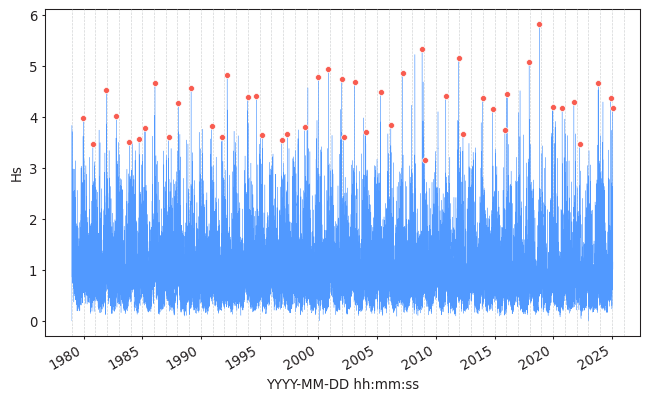

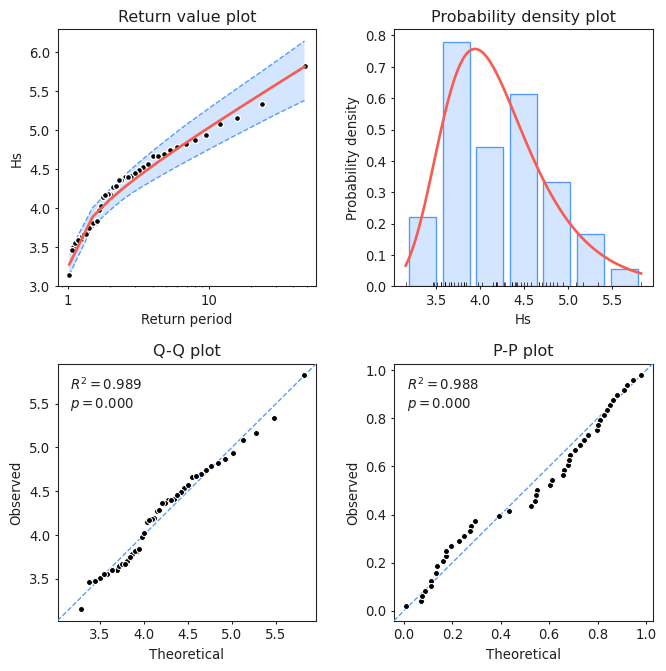

In [45]:
fig=model.plot_diagnostic(alpha=0.95)
plt.show()

## Peak Over Threshold

3.3470800000000165


/opt/miniforge3/envs/meteocean/lib/python3.10/site-packages/pyextremes/eva.py:112: RuntimeWarning: 1 duplicate indices found in `data` - removing duplicate entries
  warnings.warn(message=message, category=RuntimeWarning)


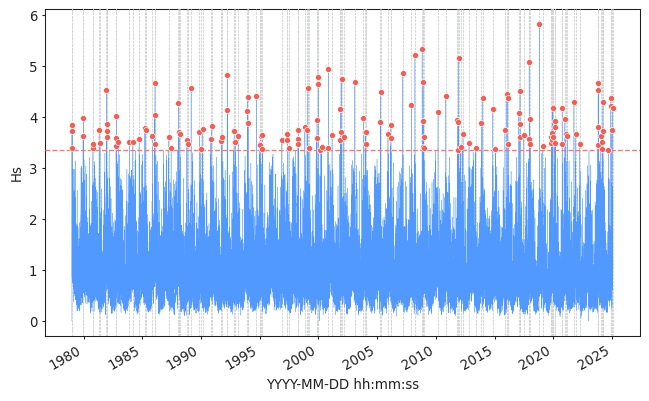

In [73]:
thrsh=pdW['Hs'].quantile(0.9975)
print(thrsh)
model = pyext.EVA(data=pdW['Hs'])
model.get_extremes("POT", threshold=thrsh, r="12h")
model.plot_extremes(show_clusters=True)
plt.show()

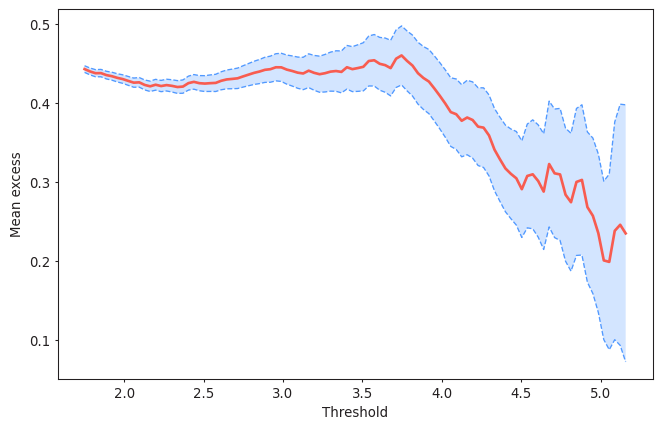

In [74]:
pyext.plot_mean_residual_life(pdW['Hs'])
plt.show()

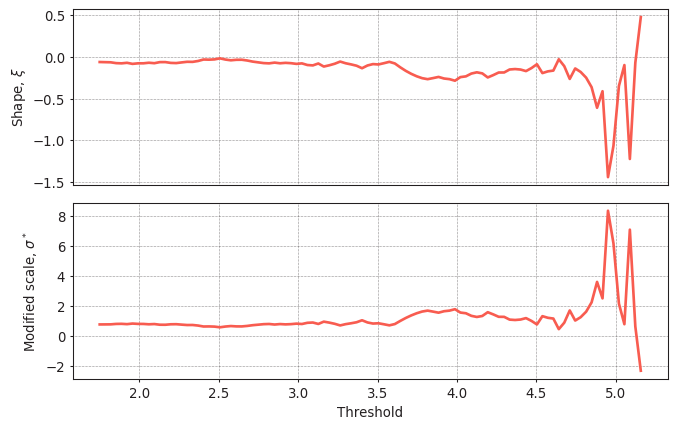

In [71]:
pyext.plot_parameter_stability(pdW['Hs'])
plt.show()

In [75]:
model.fit_model()
summary = model.get_summary(
    return_period=[1, 2, 5, 10, 25, 50, 100, 250, 500, 1000],
    alpha=0.95,
    n_samples=1000,
)
print(summary)

               return value  lower ci  upper ci
return period                                  
1.0                3.995365  3.910253  4.088834
2.0                4.354584  4.222311  4.499845
5.0                4.829445  4.634829  5.043171
10.0               5.188664  4.946886  5.454181
25.0               5.663525  5.359404  5.997507
50.0               6.022744  5.671462  6.408518
100.0              6.381962  5.983519  6.819528
250.0              6.856823  6.396037  7.362854
500.0              7.216042  6.708095  7.773865
1000.0             7.575261  7.020152  8.184875


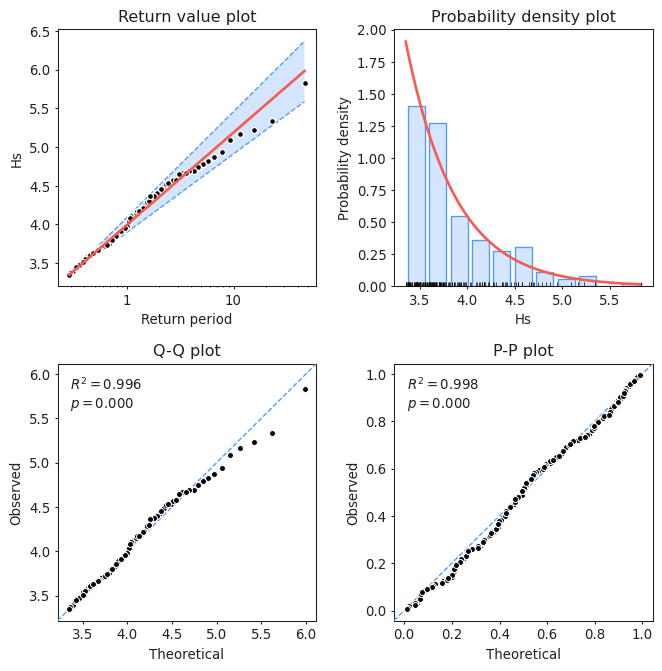

In [76]:
model.plot_diagnostic(alpha=0.95)
plt.show()